In [60]:
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt

In [61]:
def parse_data_file(filename):
    # Чтение файла и парсинг данных по каналам без сохранения во временные csv
    with open(filename, "r") as raw_data:
        channel_data = {}
        headers = {}
        channel_order = []
        while True:
            line = raw_data.readline()
            if not line:
                break
            if line.startswith("#CHANNEL"):
                ch = line.split(":")[1].strip()
                channel_order.append(ch)
                size_line = raw_data.readline()
                size = int(size_line.strip().split('=')[1])
                header_line = raw_data.readline().strip().split(",")
                headers[ch] = header_line
                channel_data[ch] = []
                for i in range(size):
                    data_line = raw_data.readline().strip().split(",")
                    channel_data[ch].append(data_line)
    # Преобразуем данные каналов в DataFrame
    dfs = {}
    for ch in channel_order:
        dfs[ch] = pd.DataFrame(channel_data[ch], columns=headers[ch])
        for col in dfs[ch].columns:
            dfs[ch][col] = pd.to_numeric(dfs[ch][col], errors='coerce')
    # Собираем итоговый DataFrame
    data = pd.DataFrame()
    # Предполагаем, что первый канал содержит время
    time_col = None
    for col in dfs[channel_order[0]].columns:
        if "Time" in col:
            time_col = col
            break
    if time_col is None:
        raise ValueError("Не найден столбец времени в первом канале")
    data["Time, s"] = dfs[channel_order[0]][time_col]
    # Добавляем все каналы
    for idx, ch in enumerate(channel_order):
        volt_col = None
        for col in dfs[ch].columns:
            if "Volt" in col:
                volt_col = col
                break
        if volt_col is not None:
            data[f"V_{idx+1}"] = dfs[ch][volt_col]
    return data


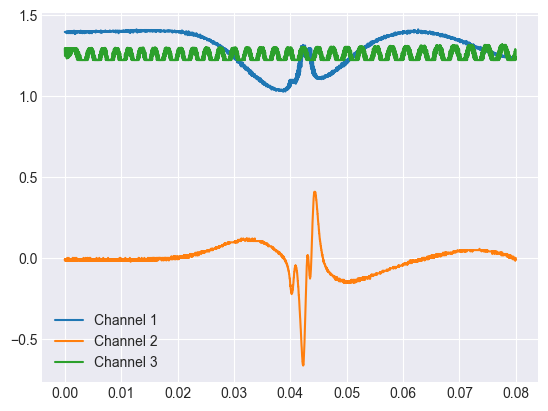

In [62]:
data_1 = parse_data_file("85_F3_SD.txt")
plt.plot(data_1["Time, s"], data_1["V_1"], label="Channel 1")
plt.plot(data_1["Time, s"], data_1["V_2"], label="Channel 2")
plt.plot(data_1["Time, s"], data_1["V_3"], label="Channel 3")
#plt.plot(data_1["Time, s"], data_1["V_4"], label="Channel 1")
plt.legend()

In [63]:
import scipy as sp
import numpy as np
import matplotlib.pyplot as plt


c = 299792458
a = 1
dnu = c/(4*a)
print(dnu*1E-6, 'MHz') # частоты между пиками интерферометра


def find_peaks_and_make_nu(data):
    x = data["Time, s"]
    y = data["Interferometer"]
    
    # Находим пики (локальные максимумы)
    peaks, properties = sp.signal.find_peaks(
        np.array(y),   
        distance=10,          # минимум 10 точек между пиками
        prominence=0.005,     # минимальная "выдающаяся" высота
        width=1
    )

    # Визуализируем результат
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(x, y, 'b-', linewidth=1, label='Исходная кривая')
    ax.plot(np.array(x)[peaks], np.array(y)[peaks], "rx", 
            markersize=8, markeredgewidth=2, label='Найденные пики')
    
    # Расчет расстояний между пиками
    peaks_x = np.array(x)[peaks]
    distances = np.diff(peaks_x)  # более элегантный способ
    
    # Добавляем информацию о расстояниях на график
    for i in range(len(peaks_x)-1):
        mid_x = (peaks_x[i] + peaks_x[i+1]) / 2
        mid_y = (np.array(y)[peaks[i]] + np.array(y)[peaks[i+1]]) / 2
        ax.annotate(f'{distances[i]*10000:.2f}', 
                   xy=(mid_x, mid_y), 
                   xytext=(0, 10), 
                   textcoords='offset points',
                   ha='center', fontsize=8, color='green')
    
    # # Вывод отладочной информации
    # print(f"Всего найдено пиков: {len(peaks)}")
    # print(f"Первые 5 расстояний (x10000): {distances[:5]*10000}")
    # print(f"Последние 5 расстояний (x10000): {distances[-5:]*10000}")
    
    # # Статистика
    # print(f"\nСтатистика расстояний:")
    # print(f"  Среднее: {np.mean(distances)*10000:.2f}")
    # print(f"  Std: {np.std(distances)*10000:.2f}")
    # print(f"  Мин: {np.min(distances)*10000:.2f}")
    # print(f"  Макс: {np.max(distances)*10000:.2f}")
    
    # Оформление графика
    ax.set_xlabel("Time, s", fontsize=12)
    ax.set_ylabel("$V_{интерферометра}$, В", fontsize=12)
    ax.set_title(f"Найденные пики (всего: {len(peaks)})", fontsize=14)
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.close()
    # plt.tight_layout()
    # plt.show()
    
    return peaks_x, distances, fig


def data_parse(file_name, show_plots=False):
    raw_data = parse_data_file(file_name)
    data = pd.DataFrame()
    data["Time, s"] = raw_data["Time, s"]
    data["Interferometer"] = raw_data["V_3"]
    data["PD"] = raw_data["V_1"]
    data["SD"] = raw_data["V_2"]


    b, a = sp.signal.butter(3, [0.01,100000], btype='band', fs=1000000)
    data["Interferometer"] = sp.signal.filtfilt(b, a, data["Interferometer"])
    peaks_x, distances, fig_peaks = find_peaks_and_make_nu(data)
    def delta_nu(t):
        if t < peaks_x[0]:
            # Extrapolate using first interval
            dt = peaks_x[1] - peaks_x[0]
            fraction = (t - peaks_x[0]) / dt
            return dnu * fraction
        elif t > peaks_x[-1]:
            # Extrapolate using last interval
            dt = peaks_x[-1] - peaks_x[-2]
            fraction = (t - peaks_x[-1]) / dt
            return dnu * (len(peaks_x) - 1 + fraction)
        else:
            # Original logic
            i = len(peaks_x[peaks_x < t]) - 1
            fraction = (t - peaks_x[i]) / (peaks_x[i+1] - peaks_x[i])
            return dnu * (i + fraction)
    
    
    data["nu"] = data["Time, s"].apply(delta_nu)
    
    fig_PD, (ax_PD, ax_PD_2) = plt.subplots(2, 1, figsize=(12, 6))
    ax_PD.plot(data["nu"], data["PD"], label="PD")
    ax_PD_2.plot(data["nu"], data["SD"], label="SD")
    ax_PD.set_xlabel("Частота, МГц")
    ax_PD.set_ylabel("Напряжение, В")
    ax_PD.legend()
    ax_PD.grid()
    plt.close()
    if show_plots:
        display(fig_PD, fig_peaks)
    return data


data = data_parse("87f2.txt")
data 

74.9481145 MHz


,"Time, s",Interferometer,PD,SD,nu
0,0.00000,-0.112913,1.094,-0.112,-2.025625e+06
1,0.00002,-0.108604,1.094,-0.104,-1.350416e+06
2,0.00004,-0.105874,1.098,-0.104,-6.752082e+05
3,0.00006,-0.105574,1.094,-0.104,0.000000e+00
4,0.00008,-0.107566,1.096,-0.096,6.752082e+05
...,...,...,...,...,...
3995,0.07990,-0.060073,1.228,0.056,2.181746e+09
3996,0.07992,-0.057941,1.230,0.056,2.182434e+09
3997,0.07994,-0.055280,1.236,0.056,2.183122e+09
3998,0.07996,-0.052207,1.236,0.056,2.183809e+09


[ 969 1230 1382 1491 1647 1808]


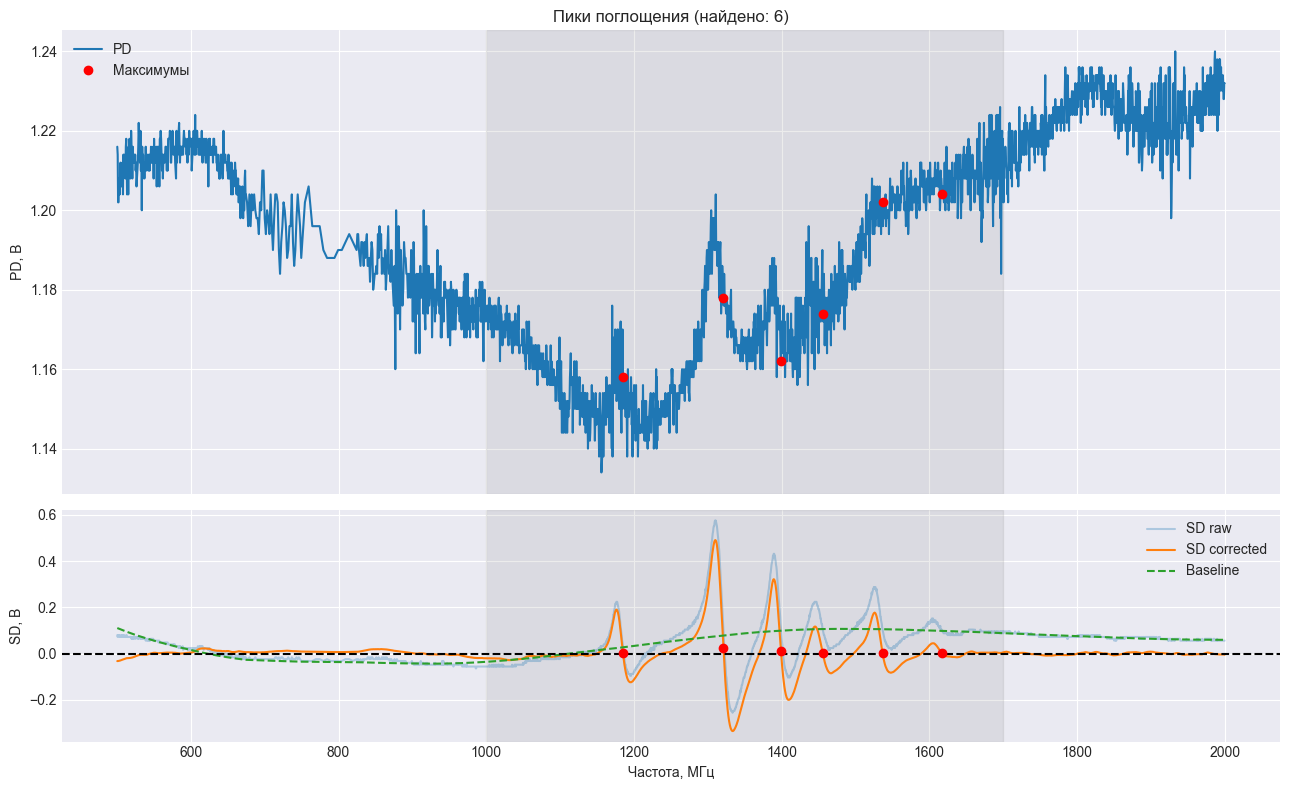

[136.03728886  77.87712127  56.65092223  81.00887992  80.61014535]
[136.03728886  77.87712127  56.65092223  81.00887992  80.61014535]


In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter


def find_peaks_poglosheniya(
    data,
    frequency_range=(0.5e9, 2e9),
    peak_range=None,
    smooth_window=31,
    baseline_window=1501,
    baseline_poly=3,
    min_distance=20
):

    # Фильтрация
    d = data[(data["nu"] >= frequency_range[0]) &
             (data["nu"] <= frequency_range[1])].reset_index(drop=True)

    freq = d["nu"].values / 1e6
    pd = d["PD"].values
    sd = d["SD"].values

    # Сглаживание
    sd_smooth = savgol_filter(sd, smooth_window, 3)

    # baseline
    baseline = savgol_filter(sd_smooth, baseline_window, baseline_poly)

    # коррекция
    sd_corr = sd_smooth - baseline

    # Нули сверху вниз (максимумы PD)
    zero_crossings = np.where(
        (sd_corr[:-1] > 0) & (sd_corr[1:] < 0)
    )[0]

    # Ручная обрезка
    if peak_range is not None:
        fmin, fmax = peak_range
        mask = (freq[zero_crossings] > fmin) & (freq[zero_crossings] < fmax)
        zero_crossings = zero_crossings[mask]

    # Удаляем близкие пики
    peaks = []
    for z in zero_crossings:
        if not peaks or z - peaks[-1] > min_distance:
            peaks.append(z)

    peaks = np.array(peaks)

    # Частоты пиков (в МГц)
    print(peaks)
    peak_freqs = freq[peaks]

    # ===== Графики =====

    plt.style.use("seaborn-v0_8-darkgrid")

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(13, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    # PD
    ax1.plot(freq, pd, label="PD")
    ax1.plot(peak_freqs, pd[peaks], "ro", label="Максимумы")

    if peak_range:
        ax1.axvspan(*peak_range, alpha=0.15, color="gray")

    ax1.set_ylabel("PD, В")
    ax1.set_title(f"Пики поглощения (найдено: {len(peaks)})")
    ax1.legend()

    # SD
    ax2.plot(freq, sd, alpha=0.3, label="SD raw")
    ax2.plot(freq, sd_corr, label="SD corrected")
    ax2.plot(freq, baseline, label="Baseline", linestyle="--")
    ax2.axhline(0, color="black", linestyle="--")
    ax2.plot(peak_freqs, sd_corr[peaks], "ro")

    if peak_range:
        ax2.axvspan(*peak_range, alpha=0.15, color="gray")

    ax2.set_xlabel("Частота, МГц")
    ax2.set_ylabel("SD, В")
    ax2.legend()

    plt.tight_layout()
    plt.show()
    print(np.array([peak_freqs[i]-peak_freqs[i-1] for i in range(1, len(peak_freqs))]))
    return peak_freqs

# запуск
data_87f2_better = data_parse("87f2_better.txt", show_plots=False)

peaks = find_peaks_poglosheniya(
    data_87f2_better, frequency_range=(0.5e9, 2e9),
    peak_range=(1000, 1700),  # МГц
    baseline_poly=3,
    baseline_window=1700
)
np.array([peaks[i]-peaks[i-1] for i in range(1, len(peaks))])
print(np.array([peaks[i]-peaks[i-1] for i in range(1, len(peaks))]))

[ 804 1357 1678 1954 2274 2623]


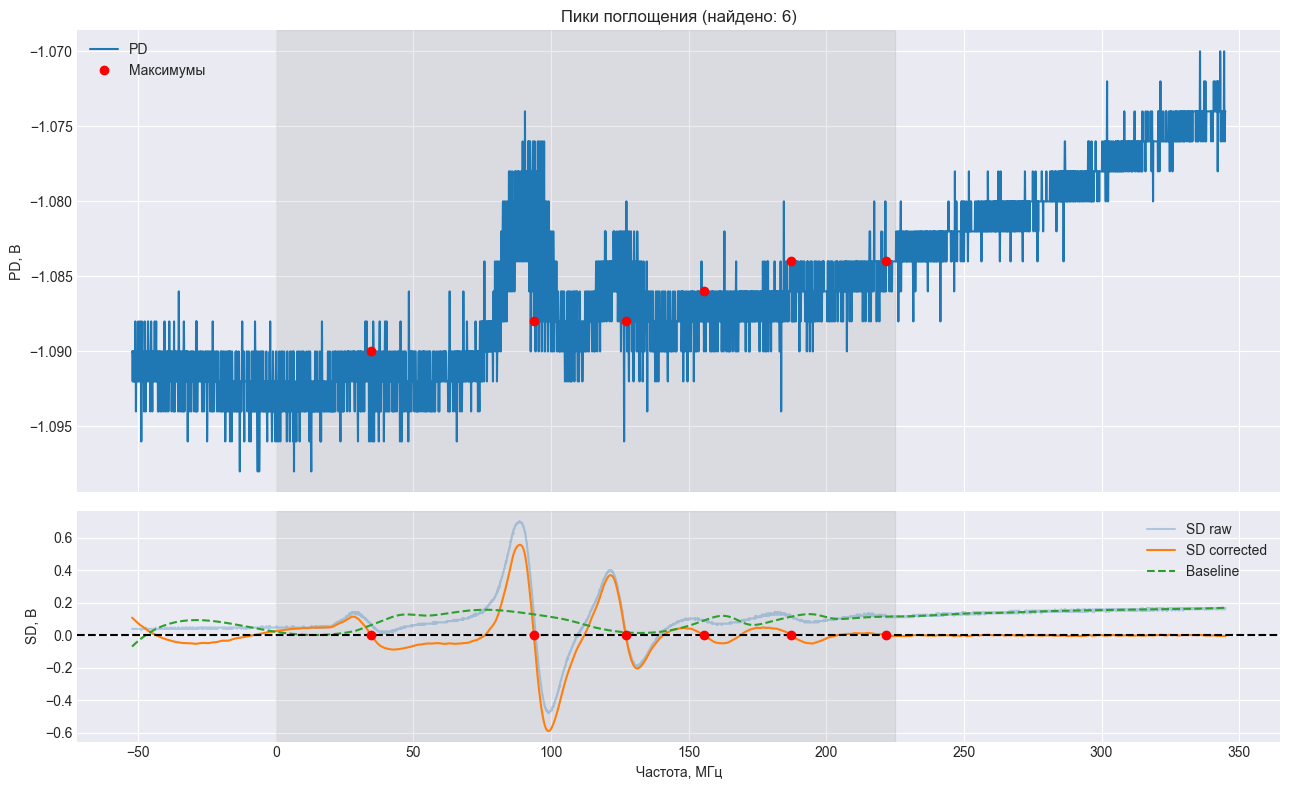

[59.02082005 33.32180714 28.38908779 31.72406963 34.59906344]


array([ 34.7162262 ,  93.73704625, 127.05885339, 155.44794119,
       187.17201081, 221.77107425])

In [80]:
data_general_picture = data_parse("General_sd_picture.txt", show_plots=False)
data_85f3 = data_parse("norm_85_f3.txt", show_plots=False)
data_85f3["SD"] = data_85f3["SD"]
find_peaks_poglosheniya(
    data_85f3, frequency_range=(-1e8, 5e8),
    peak_range=(0, 225), baseline_poly=4, baseline_window=1500  # МГц
)

C:\Users\RedBrean\AppData\Local\Temp\ipykernel_21384\245051794.py:96: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(


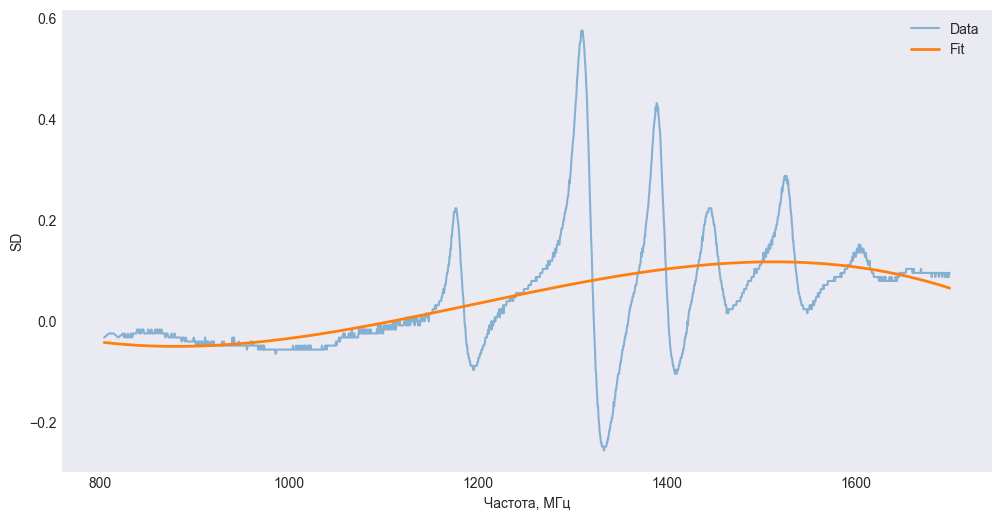

(array([ 1.82065173e+00, -5.27196493e-03,  4.73682049e-06, -1.31936965e-09,
        -3.53810816e+01,  2.02401042e+04,  2.43952469e+06,  2.94084899e+00,
         8.23661177e+04,  8.50744135e+04, -2.18507742e+03,  1.29448276e+06,
         3.82294669e+07,  1.51808148e+01,  4.69016034e+04, -1.73134216e+04,
        -2.17802733e+03, -2.14456910e+06, -1.20473818e+04, -3.35173814e+04,
        -6.53240078e+07, -6.61038202e+07]),
 array([[inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
         inf, inf, inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
         inf, inf, inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
         inf, inf, inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, inf,
         inf, inf, inf, inf, inf, inf, inf, inf, inf],
        [inf, inf, inf, inf, inf, inf, inf, inf, inf, inf, i

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


# ---------- Модели ----------

def gaussian_derivative(x, A, x0, sigma):
    return A * (x - x0) / sigma**2 * np.exp(-(x - x0)**2 / (2 * sigma**2))


def lorentzian_derivative(x, A, x0, gamma):
    return A * (x - x0) / ((x - x0)**2 + gamma**2)**2


def polynomial(x, *coeffs):
    return sum(c * x**i for i, c in enumerate(coeffs))


# ---------- Общая модель ----------

def build_model(n_peaks=4, baseline="poly", poly_order=2):

    def model(x, *params):

        idx = 0

        # ---------- baseline ----------
        if baseline == "gaussian":
            A, x0, sigma = params[idx:idx+3]
            y = gaussian_derivative(x, A, x0, sigma)
            idx += 3

        elif baseline == "poly":
            coeffs = params[idx:idx+poly_order+1]
            y = polynomial(x, *coeffs)
            idx += poly_order + 1

        else:
            y = 0

        # ---------- маленькие пики ----------
        for _ in range(n_peaks):
            A, x0, gamma = params[idx:idx+3]
            y += lorentzian_derivative(x, A, x0, gamma)
            idx += 3

        return y

    return model


# ---------- Основная функция ----------

def fit_saturated_absorption(
    data,
    n_peaks=5,
    baseline="gaussian",
    poly_order=2,
    peak_range=None,
    initial_params=None
):

    d = data.copy()

    if peak_range:
        d = d[(d["nu"]/1e6 > peak_range[0]) &
              (d["nu"]/1e6 < peak_range[1])]

    x = d["nu"].values / 1e6
    y = d["SD"].values

    model = build_model(n_peaks, baseline, poly_order)

    # ---------- начальные параметры ----------
    if initial_params is None:

        params = []

        # baseline
        if baseline == "gaussian":
            params += [0.01, np.mean(x), 200]

        elif baseline == "poly":
            params += [0]*(poly_order+1)

        # пики
        peak_positions = np.linspace(x.min(), x.max(), n_peaks)

        for pos in peak_positions:
            params += [0.005, pos, 10]

        initial_params = params

    # ---------- фит ----------
    popt, pcov = curve_fit(
        model,
        x,
        y,
        p0=initial_params,
        maxfev=20000
    )

    # ---------- графики ----------

    x_fit = np.linspace(x.min(), x.max(), 2000)
    y_fit = model(x_fit, *popt)

    plt.figure(figsize=(12,6))
    plt.plot(x, y, label="Data", alpha=0.5)
    plt.plot(x_fit, y_fit, label="Fit", linewidth=2)

    plt.xlabel("Частота, МГц")
    plt.ylabel("SD")
    plt.legend()
    plt.grid()

    plt.show()

    return popt, pcov

fit_saturated_absorption(
    data_87f2_better,
    n_peaks=6,
    baseline="poly",
    poly_order=3,
    peak_range=(800,1700)

)